In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("API_KEY")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mosqlient.scoring import Scorer

In [3]:
import matplotlib as mpl
from epiweeks import Week
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Set date format with newline between month and year
date_fmt = mdates.DateFormatter('%b\n%Y')  # e.g., Jun\n2025

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font siz

In [4]:
df_ens_lin_end_equal= pd.read_csv('ensemble_lin_equal.csv', usecols = ['lower_95', 'lower_80', 'lower_50', 'pred', 'upper_50', 'upper_80', 'upper_95', 'date', 'epiweek'])
df_ens_log_end_equal= pd.read_csv('ensemble_log_equal.csv', usecols = ['lower_95', 'lower_80', 'lower_50', 'pred', 'upper_50', 'upper_80', 'upper_95', 'date', 'epiweek'])
df_ens_log_end_equal.head()

,lower_95,lower_80,lower_50,pred,upper_50,upper_80,upper_95,date,epiweek
0,327048.955940,336028.497458,344272.448318,353669.488133,363323.023517,372236.604285,382456.829672,2020-10-24,2020-10-18
1,298415.720500,311013.254381,322736.055334,336279.857963,350392.033994,363599.111224,378948.343211,2020-10-31,2020-10-18
2,278685.916699,292003.635818,304459.339243,318922.613723,334072.962900,348323.175013,364968.688581,2020-11-07,2020-10-18
3,269105.230572,283579.991504,297191.227099,313081.832965,329822.098349,345652.856580,364244.997855,2020-11-14,2020-10-18
4,463081.637586,466518.323655,469615.180108,473080.127927,476570.641068,479734.227127,483294.497717,2020-10-31,2020-10-25


In [5]:
df_covidhub = pd.read_csv('covidhub_untrained.csv')

for col in ['epiweek', 'date']:

    df_covidhub[col] = pd.to_datetime(df_covidhub[col]).dt.date

df_covidhub = df_covidhub.loc[df_covidhub.date >= pd.to_datetime('2020-07-25').date()]
df_covidhub.head()

,date,epiweek,horizon,lower_95,lower_80,lower_50,pred,upper_50,upper_80,upper_95
10,2020-07-25,2020-07-03,3,72781.236416,117220.749834,174563.135125,270434.643880,391554.214267,526544.961539,744789.315553
11,2020-07-25,2020-07-05,3,355819.000000,376707.000000,399378.000000,432016.000000,468796.000000,497951.853652,522656.000000
12,2020-07-25,2020-07-06,3,146133.160394,183242.905015,224930.840861,283970.369681,338661.421350,367118.024201,385952.145927
13,2020-07-25,2020-07-07,2,73109.862563,101794.818364,127692.046472,156465.714844,185239.383216,211136.611324,239821.567125
14,2020-07-25,2020-07-09,2,117081.323115,174755.524757,238861.215888,332766.638442,450276.108491,548383.097341,711862.751111


In [6]:
df_ens_lin_end_equal['horizon'] = np.nan 
df_ens_log_end_equal['horizon'] = np.nan 

for df_ in [df_ens_lin_end_equal, df_ens_log_end_equal]: 

    for col in ['epiweek', 'date']:

        df_[col] = pd.to_datetime(df_[col]).dt.date

    for dt_ in df_.epiweek.unique(): 
        df_.loc[df_.epiweek == dt_, 'horizon'] = [1,2,3,4]

df_ens_lin_end_equal.head()

,lower_95,lower_80,lower_50,pred,upper_50,upper_80,upper_95,date,epiweek,horizon
0,91770.105525,94704.113649,96744.634372,98346.070808,99307.222129,99745.484942,99939.102742,2020-10-24,2020-10-18,1.0
1,80528.849266,87373.965758,92214.829632,96037.403567,98338.155978,99388.739653,99853.181833,2020-10-31,2020-10-18,2.0
2,78659.963515,85960.792783,91196.751830,95445.726596,98069.238277,99286.110838,99828.069542,2020-11-07,2020-10-18,3.0
3,78833.372050,85952.756258,91133.301829,95388.199164,98038.372491,99273.581330,99824.925686,2020-11-14,2020-10-18,4.0
4,83467.080795,89134.954768,93224.382170,96519.282988,98532.371604,99458.925540,99869.948955,2020-10-31,2020-10-25,1.0


In [7]:
df_ens_lin_end_equal = df_ens_lin_end_equal.sort_values(by = ['epiweek', 'date'])

df_ens_log_end_equal = df_ens_log_end_equal.sort_values(by = ['epiweek', 'date'])

In [8]:
df_ens_lin_end_equal['key'] = list(zip(df_ens_lin_end_equal['epiweek'], 
                                       df_ens_lin_end_equal['date'],
                                       df_ens_lin_end_equal['horizon']))

df_ens_log_end_equal['key'] = list(zip(df_ens_log_end_equal['epiweek'], 
                                       df_ens_log_end_equal['date'],
                                       df_ens_log_end_equal['horizon']))


In [9]:
df_ens_lin_end_equal.shape

(1068, 11)

In [10]:
df_ens_lin_end_equal = df_ens_lin_end_equal.loc[df_ens_lin_end_equal.date >= pd.to_datetime('2020-07-25').date()]

df_ens_log_end_equal = df_ens_log_end_equal.loc[df_ens_log_end_equal.date >= pd.to_datetime('2020-07-25').date()]


In [11]:
df_preds = pd.read_parquet('./data/fullforecasts.parquet')

df_preds = df_preds.loc[df_preds.model == 'COVIDhub-4_week_ensemble']

df_ensemble = pd.concat([df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.025)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'lower_95', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']), 
            
      #      df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.05)][['model', 'forecast_date', 'horizon',
      #'target_end_date', 'value']].rename(columns = {'value': 'lower_90', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']),           

            df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.1)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'lower_80', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']),           

             df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.25)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'lower_50', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']),           

            df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.5)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'pred', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']), 

            df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.75)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'upper_50', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']),

            df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.9)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'upper_80', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']),

      #      df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.95)][['model', 'forecast_date', 'horizon',
      #'target_end_date', 'value']].rename(columns = {'value': 'upper_90', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date']),

            df_preds.loc[(df_preds.type == 'quantile') & (df_preds['quantile'] == 0.975)][['model', 'forecast_date', 'horizon',
      'target_end_date', 'value']].rename(columns = {'value': 'upper_95', 'forecast_date':'epiweek', 'target_end_date':'date'}).set_index(['model', 'epiweek', 'horizon', 'date'])], axis =1).reset_index()

df_ensemble['horizon'] = df_ensemble['horizon'].astype(float)
df_ensemble.head()

,model,epiweek,horizon,date,lower_95,lower_80,lower_50,pred,upper_50,upper_80,upper_95
0,COVIDhub-4_week_ensemble,2020-07-20,1.0,2020-07-25,354703.0,433849.0,471764.0,528883.0,563543.0,585873.0,689024.0
1,COVIDhub-4_week_ensemble,2020-07-20,2.0,2020-08-01,290371.0,393021.0,455740.0,537671.0,595235.0,648353.0,802663.0
2,COVIDhub-4_week_ensemble,2020-07-20,3.0,2020-08-08,249289.0,355480.0,422267.0,508963.0,598392.0,675872.0,869474.0
3,COVIDhub-4_week_ensemble,2020-07-20,4.0,2020-08-15,224612.0,329643.0,390086.0,495729.0,593397.0,696521.0,946794.0
4,COVIDhub-4_week_ensemble,2020-07-27,1.0,2020-08-01,390056.0,413333.0,421784.0,454323.0,485925.0,513596.0,526253.0


In [12]:
df_ensemble['key'] = list(zip(df_ensemble['epiweek'], 
                                       df_ensemble['date'],
                                       df_ensemble['horizon']))

In [13]:
df_ens_lin = df_ens_lin_end_equal.loc[df_ens_lin_end_equal.key.isin(df_ensemble.key.unique())]

df_ens_log = df_ens_log_end_equal.loc[df_ens_log_end_equal.key.isin(df_ensemble.key.unique())]

In [14]:
print(df_ens_lin.date.min(), df_ens_lin.date.max())
print(df_ens_log.date.min(), df_ens_log.date.max())
print(df_ensemble.date.min(), df_ensemble.date.max())
print(df_covidhub.date.min(), df_covidhub.date.max())

2020-07-25 2022-04-09
2020-07-25 2022-04-09
2020-07-25 2022-04-09
2020-07-25 2022-04-09


In [15]:
covid_data = pd.read_parquet('./data/covid_truth_data.parquet', 
                            columns = ['target_end_date', 'value'])

covid_data = covid_data.rename(columns = {'target_end_date':'date', 
                                          'value':'casos'})

print(covid_data.date.min(), covid_data.date.max())

2020-01-25 2023-03-04


In [16]:
step = 1


In [17]:
df_ens_ = df_ensemble.loc[df_ensemble.horizon == step][['date', 'lower_95', 'lower_80', 'lower_50',
                                            'pred', 'upper_50', 'upper_80', 'upper_95']]

df_hub_ = df_covidhub.loc[df_covidhub.horizon == step][['date', 'lower_95', 'lower_80', 'lower_50',
                                            'pred', 'upper_50', 'upper_80', 'upper_95']]

df_ens_lin_ = df_ens_lin.loc[df_ens_lin.horizon == step][['date', 'lower_95', 'lower_80', 'lower_50',
                                            'pred', 'upper_50', 'upper_80', 'upper_95']]

df_ens_log_ = df_ens_log.loc[df_ens_log.horizon == step][['date', 'lower_95', 'lower_80', 'lower_50',
                                            'pred', 'upper_50', 'upper_80', 'upper_95']]


In [20]:
df_ens_

,date,lower_95,lower_80,lower_50,pred,upper_50,upper_80,upper_95
0,2020-07-25,354703.0,433849.0,471764.0,528883.0,563543.0,585873.0,689024.0
4,2020-08-01,390056.0,413333.0,421784.0,454323.0,485925.0,513596.0,526253.0
8,2020-08-08,367977.0,389299.0,410424.0,434142.0,452867.0,482542.0,528801.0
12,2020-08-15,308971.0,318973.0,352384.0,375174.0,394785.0,418031.0,461211.0
16,2020-08-22,298148.0,308736.0,320857.0,333170.0,353815.0,373532.0,405935.0
...,...,...,...,...,...,...,...,...
328,2022-02-19,472686.0,592618.0,723449.0,872965.0,984537.0,1152901.0,1386938.0
332,2022-02-26,289004.0,359341.0,442991.0,569097.0,583620.0,704818.0,831584.0
336,2022-03-05,207926.0,276954.0,304617.0,380875.0,419020.0,547528.0,729307.0
340,2022-03-12,120183.0,157914.0,193042.0,265703.0,309564.0,347838.0,403450.0


In [19]:
df_hub_

,date,lower_95,lower_80,lower_50,pred,upper_50,upper_80,upper_95
17,2020-07-25,198928.347266,266719.938767,335834.092233,433016.544217,519550.274679,565552.052263,6.944936e+05
18,2020-07-25,612999.598454,663171.883152,721934.479301,801208.648393,889805.841443,983913.464226,1.108573e+06
19,2020-07-25,420572.452598,478236.500000,493188.500000,516284.512301,537804.000000,562174.781879,5.891480e+05
20,2020-07-25,354703.000000,430367.781652,453717.904876,462365.412320,469979.197333,481077.743904,5.170764e+05
32,2020-08-01,246546.380511,284605.563228,326990.438332,383210.181446,452153.531862,526086.708813,6.263831e+05
...,...,...,...,...,...,...,...,...
1040,2022-03-19,56603.000000,68638.000000,77656.000000,87957.000000,99191.000000,109530.000000,1.135570e+05
1041,2022-03-19,98785.000000,125260.000000,135064.000000,144149.000000,159364.000000,172381.000000,1.877370e+05
1042,2022-03-19,107482.000000,129171.000000,144865.000000,156295.000000,165961.000000,179151.000000,1.930610e+05
1043,2022-03-19,124001.252656,141398.087030,151580.000000,202711.660169,232044.540856,247872.325698,3.509010e+05


In [18]:
score_hub_ = Scorer("eduardocorrearaujo:00566e8d-b64b-44a3-83b7-b50a086096e0",
                      df_true = covid_data,
                      pred=df_hub_,
                      dist='log_normal',
                      fn_loss='median',
                      conf_level=0.95)

print(score_hub_.crps[1]['pred'])
print(score_hub_.wis[1]['pred'])
print(score_hub_.log_score[1]['pred'])
print(np.sqrt(score_hub_.mse['pred']))

ValueError: operands could not be broadcast together with shapes (87,) (260,) 

In [20]:
score_ens_ = Scorer("eduardocorrearaujo:00566e8d-b64b-44a3-83b7-b50a086096e0",
                      df_true = covid_data,
                      pred=df_ens_,
                      dist='log_normal',
                      fn_loss='median',
                      conf_level=0.95)

print(score_ens_.crps[1]['pred'])
print(score_ens_.wis[1]['pred'])
print(score_ens_.log_score[1]['pred'])
print(np.sqrt(score_ens_.mse['pred']))

109674.41626303448
91602.27947454843
-13.083650214237124
330911.84808861907


In [21]:
score_lin_ = Scorer("eduardocorrearaujo:00566e8d-b64b-44a3-83b7-b50a086096e0",
                      df_true = covid_data,
                      pred=df_ens_lin_,
                      dist='log_normal',
                      fn_loss='median',
                      conf_level=0.95)

print(score_lin_.crps[1]['pred'])
print(score_lin_.wis[1]['pred'])
print(score_lin_.log_score[1]['pred'])
print(np.sqrt(score_lin_.mse['pred']))

785110.6611864847
782875.7874961663
-84.03149697396552
1281236.409595206


In [22]:
score_log_ = Scorer("eduardocorrearaujo:00566e8d-b64b-44a3-83b7-b50a086096e0",
                      df_true = covid_data,
                      pred=df_ens_log_,
                      dist='log_normal',
                      fn_loss='median',
                      conf_level=0.95)

print(score_log_.crps[1]['pred'])
print(score_log_.wis[1]['pred'])
print(score_log_.log_score[1]['pred'])
print(np.sqrt(score_log_.mse['pred']))

109938.12544923881
98540.73005514173
-20.910821061506937
294913.7190473518


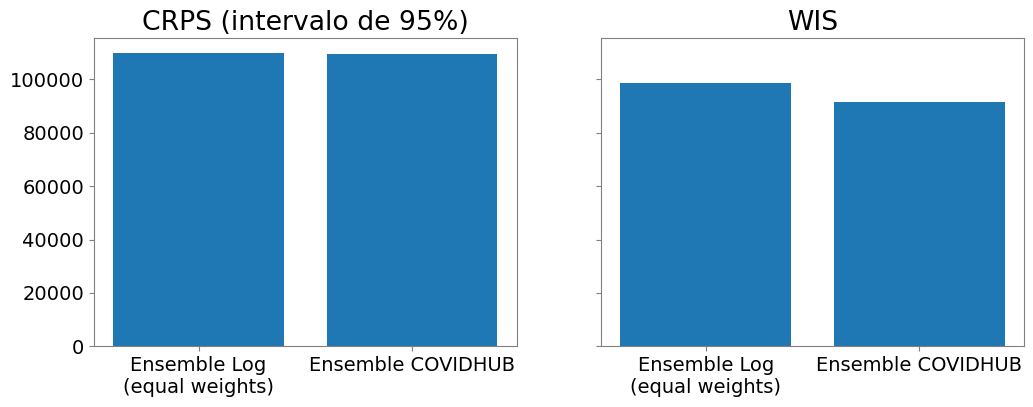

In [23]:
_, ax= plt.subplots(1,2, figsize = (12,4), sharey = True)

#ax.bar(['Ensemble linear', 'Ensemble Log', 'Ensemble COVIDHUB'], [score_lin_.crps[1]['pred'], score_log_.crps[1]['pred'], score_ens_.crps[1]['pred']])
ax[0].bar(['Ensemble Log\n(equal weights)', 'Ensemble COVIDHUB'], [ score_log_.crps[1]['pred'], score_ens_.crps[1]['pred']])

ax[0].set_title('CRPS (intervalo de 95%)')

ax[1].bar(['Ensemble Log\n(equal weights)', 'Ensemble COVIDHUB'], [ score_log_.wis[1]['pred'], score_ens_.wis[1]['pred']])

ax[1].set_title('WIS')

plt.subplots_adjust()

plt.show()